This is for the ROoco dataset from the hugginface. There is some unneccesary code. Avoid it.

In [ ]:
!pip install git+https://github.com/huggingface/transformers.git@main

  Cloning https://github.com/huggingface/transformers.git (to revision main) to /tmp/pip-req-build-bqipeq4q
  Running command git clone --filter=blob:none --quiet https://github.com/huggingface/transformers.git /tmp/pip-req-build-bqipeq4q
  Resolved https://github.com/huggingface/transformers.git to commit 277db238b70c5c8bb5a445b75becbfd79644db42
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
!pip install -q datasets

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from datasets import load_dataset
orginal = load_dataset("gaodrew/roco-65k-256px", split = "train")

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Generating train split:   0%|          | 0/65418 [00:00<?, ? examples/s]

In [ ]:
#@title dataset divider
from torch.utils.data import Subset

# Define the indices for each dataset
indices_1 = range(0, 5000)
indices_2 = range(5000, 10000)
indices_3 = range(10000, 15000)
indices_4 = range(15000, 20000)
indices_5 = range(20000, 25000)
indices_6 = range(25000, 30000)
indices_7 = range(30000, 35000)
indices_8 = range(35000, 40000)
indices_9 = range(40000, 45000)
indices_10 = range(45000, 50000)
indices_11 = range(50000, 55000)
indices_12 = range(55000, 60000)
xtra = range(60000, 61000)

# Create Subset objects using the defined indices and name them as dataset_1, dataset_2, etc.
dataset_1 = Subset(orginal, indices_1)
dataset_2 = Subset(orginal, indices_2)
dataset_3 = Subset(orginal, indices_3)
dataset_4 = Subset(orginal, indices_4)
dataset_5 = Subset(orginal, indices_5)
dataset_6 = Subset(orginal, indices_6)
dataset_7 = Subset(orginal, indices_7)
dataset_8 = Subset(orginal, indices_8)
dataset_9 = Subset(orginal, indices_9)
dataset_10 = Subset(orginal, indices_10)
dataset_11 = Subset(orginal, indices_11)
dataset_12 = Subset(orginal, indices_12)
xtra = Subset(orginal, xtra)

# Check the length of the last subset (xtra)
print(len(xtra))


1000


In [ ]:
# Lagbe
from torch.utils.data import random_split
# Split the dataset into train and validation sets (80-10-10)
r = len(xtra)
val_size = int(0.5 * r)
test_size = int(0.5 * r)
validition_dataset,testing_dataset= random_split(xtra, [val_size,test_size])
print(f'validation dataset : {len(validition_dataset)} testing dataset : {len(testing_dataset)}')

validation dataset : 500 testing dataset : 500


In [ ]:
from torch.utils.data import Dataset, DataLoader

class ImageCaptioningDataset(Dataset):
    def __init__(self, dataset, processor):
        self.dataset = dataset
        self.processor = processor

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        item = self.dataset[idx]
        encoding = self.processor(images=item["image"], text=item["text"], padding="max_length", return_tensors="pt")
        # remove batch dimension
        encoding = {k:v.squeeze() for k,v in encoding.items()}
        return encoding

In [ ]:
import torch
from transformers import AutoProcessor, BlipForConditionalGeneration

save_path = '/content/drive/MyDrive/blip-image-captioning-BASE_By_roco.pth'

processor = AutoProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base")
model.load_state_dict(torch.load(save_path))

/usr/local/lib/python3.10/dist-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.56k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

<All keys matched successfully>

In [ ]:
train_dataset = ImageCaptioningDataset(dataset_4, processor)
train_dataloader = DataLoader(train_dataset, shuffle=True, batch_size=1)
val_dataset = ImageCaptioningDataset(validition_dataset, processor)
val_dataloader = DataLoader(val_dataset, shuffle=True, batch_size=1)

In [ ]:
#@title Beep Function
from google.colab import output
def I_am_Done ():
  output.eval_js('new Audio("https://upload.wikimedia.org/wikipedia/commons/0/05/Beep-09.ogg").play()')

In [ ]:
#@title Training Code
import torch
from statistics import mean
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer, AutoConfig
from datasets import load_metric, Dataset, DatasetDict
from torch.utils.data import DataLoader
from tqdm.auto import tqdm  # Optional for progress bar

optimizer = torch.optim.AdamW(model.parameters(), lr=6e-6)

# Device selection (GPU if available)
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

# Training hyperparameters
num_epochs = 1  # Adjust as needed
patience = 5  # Number of epochs to wait for improvement (for early stopping)
best_val_loss = float("inf")  # Initialize best validation loss
current_patience = 0  # Initialize current_patience outside the loop
image_cnt = 0

def train(train_dataloader, val_dataloader):
  global image_cnt
  model.train()
  train_loss = 0.0

  for batch in tqdm(train_dataloader, desc="Training"):  # Optional progress bar
    batch = {k: v.to(device) for k, v in batch.items()}

    # Forward pass
    input_ids = batch.pop("input_ids").to(device)
    pixel_values = batch.pop("pixel_values").to(device)

    outputs = model(input_ids=input_ids,
                    pixel_values=pixel_values,
                    labels=input_ids)
    loss = outputs.loss

    # Backward pass and optimization
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    train_loss = train_loss + loss.item()

  # Validation after each epoch
  # val_loss = evaluate(val_dataloader)
  # print(f'Epoch {epoch} - Train Loss: {train_loss / len(train_dataloader):.4f}, Val Loss: {val_loss:.4f}')
  print(f'Epoch {epoch} - Train Loss: {train_loss / len(train_dataloader):.4f}')


  # Early stopping (optional)
  # global best_val_loss
  # if val_loss < best_val_loss:
  #   best_val_loss = val_loss
  #   current_patience = 0  # Reset patience counter if loss improves
  # else:
  #   current_patience += 1
  # if current_patience >= patience:
  #   print(f'Early stopping at epoch {epoch} due to no improvement in validation loss')
  #   return  # Exit training loop if patience is exhausted

def evaluate(dataloader):
  model.eval()
  eval_loss = 0.0
  image_cnt = 0
  with torch.no_grad():
    for batch in dataloader:
      batch = {k: v.to(device) for k, v in batch.items()}
      if image_cnt > 50:
        break
      else:
        image_cnt = image_cnt + 1
      input_ids = batch.pop("input_ids").to(device)
      pixel_values = batch.pop("pixel_values").to(device)

      outputs = model(input_ids=input_ids,
                    pixel_values=pixel_values,
                    labels=input_ids)


      loss = outputs.loss

      eval_loss = eval_loss + loss.item()

  return eval_loss / len(dataloader)


for epoch in range(num_epochs):
  train(train_dataloader, val_dataloader)
  give_me_bleu(testing_dataset)
I_am_Done ()


Training:   0%|          | 0/5000 [00:00<?, ?it/s]

RuntimeError: The size of tensor a (521) must match the size of tensor b (512) at non-singleton dimension 1

In [ ]:
# torch.save(model.state_dict(), save_path)
print("Not Printed")
# print("Printed")

In [ ]:
from google.colab import drive
import torch

# Mount Google Drive
drive.mount('/content/drive')

# Define the path where you want to save the model in your Google Drive
save_path = '/content/drive/MyDrive/blip-image-captioning-BASE_By_roco.pth'

# Assuming you have already initialized and trained your model and named it 'model'
# Save the model to the specified path
torch.save(model.state_dict(), save_path)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Saving chest radiograph bilateral alveolar opacities and cardiomegaly ..jpg to chest radiograph bilateral alveolar opacities and cardiomegaly ..jpg


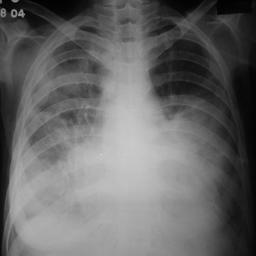

In [ ]:
from google.colab import files

# Upload an image file
uploaded = files.upload()

file_name = list(uploaded.keys())[0]

# Read the uploaded image file
import io
from PIL import Image

image = Image.open(io.BytesIO(uploaded[file_name]))

# Display the uploaded image
image

In [ ]:
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

# prepare image for the model
inputs = processor(images=image, return_tensors="pt").to(device)
pixel_values = inputs.pixel_values

generated_ids = model.generate(pixel_values=pixel_values, max_length=200)
generated_caption = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
print(generated_caption)

chest x - ray showing a large right - sided pneumothorax with a large right - sided pneumothorax


**Bleu**

In [ ]:
def Caption(model, processor, image):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model.to(device)
    inputs = processor(images=image,return_tensors="pt").to(device)
    generated_ids = model.generate(pixel_values=inputs.pixel_values, max_length=50)
    generated_caption = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
    return generated_caption

In [ ]:
!pip install evaluate
import evaluate, torch
bleu = evaluate.load('bleu')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.0 MB/s eta 0:00:00


In [ ]:
# ----------------------------Calculate the real Bleu score--------------------------------------
def give_me_bleu(testing_dataset):
  import matplotlib.pyplot as plt
  image_bleu_scores = []
  image_cnt = 1
  for id in testing_dataset:

    # print ("Image No: ", image_cnt)
    image = id['image']
    text = id['text']
    caption = Caption(model, processor, image)

    references, predictions = [], []
    references.append(text)
    predictions.append(caption)

    results = bleu.compute(predictions=predictions, references=references, max_order = 2)

    # if results['bleu'] > 0.7:
    #   print("Reference Text: ", text)
    #   print("Predicted Text: ", caption)

    image_bleu_scores.append(results['bleu'])
    image_cnt = image_cnt + 1

  final_bleu_score = sum(image_bleu_scores) / len(image_bleu_scores)
  print("Overall BLEU Score: %.3f" % final_bleu_score)


  # ---------------Code for scatter plot------------------ #
  bleu_scores = list(image_bleu_scores)  # Extract all BLEU scores as a list
  plt.scatter(range(len(bleu_scores)), bleu_scores)  # Use range(len()) for x-axis

  # Customization (optional)
  plt.xlabel("Image Index")
  plt.ylabel("BLEU Score")
  plt.title("BLEU Scores vs. Image Index")
  plt.grid(True)

  # Display the plot
  plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import torch
from transformers import AutoProcessor, BlipForConditionalGeneration

processor = AutoProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base")
model.load_state_dict(torch.load(save_path))

In [ ]:
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
model_tuned.to(device)
image = dataset[401]["image"]
inputs = processor(images=image, return_tensors="pt").to(device)
pixel_values = inputs.pixel_values
generated_ids = model_tuned.generate(pixel_values=pixel_values, max_length=50)
generated_caption = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
print(generated_caption)

there is a street with a stop sign on the side of it


For saving the modelto google drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from google.colab import drive
import torch

# Mount Google Drive
drive.mount('/content/drive')

# Define the path where you want to save the model in your Google Drive
save_path = '/content/drive/My Drive/blip-image-captioning-base_By_GTA.pth'

# Assuming you have already initialized and trained your model and named it 'model'
# Save the model to the specified path
torch.save(model_fine.state_dict(), save_path)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **Base and Large Model**

In [ ]:
from transformers import AutoProcessor, BlipForConditionalGeneration

processor_base= AutoProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
model_base= BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base")

model_large = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-large")
processor_large= AutoProcessor.from_pretrained("Salesforce/blip-image-captioning-large")

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:88: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

...

preprocessor_config.json:   0%|          | 0.00/445 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/527 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

In [ ]:
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
text = "there is a"
model_base.to(device)
inputs_base = processor_base(images=image, text=text, return_tensors="pt").to(device)
outputs_base = model_base(**inputs_base)

# Large
model_large.to(device)
inputs_large = processor_large(images=image, text=text, return_tensors="pt").to(device)
outputs_large = model_large(**inputs_large)

# Fine Tune
# model_fine.to(device)
# inputs_fine = processor_fine(images=image, text=text, return_tensors="pt").to(device)
# outputs_fine = model_fine(**inputs_fine)

In [ ]:
# a = outputs_fine.logits
b = outputs_base.logits
c = outputs_large.logits

In [ ]:
final_logits = a - b + c

In [ ]:
# model_large.to(device)
# inputs_large = processor_large(images=image, return_tensors="pt").to(device)
# outputs_large = model_large.generate(**inputs_large)
# print(processor_large.decode(outputs_large.logits, skip_special_tokens=True))
# outputs_large.logits

In [ ]:
print(a)

tensor([[[ 2.5993, -3.9166, -3.9166,  ..., -3.9164, -3.9162, -3.9162],
         [ 2.5993, -3.9166, -3.9166,  ..., -3.9164, -3.9162, -3.9162]]],
       device='cuda:0', grad_fn=<ViewBackward0>)


In [ ]:
generated_tokens = []

predictions = torch.softmax(outputs_large.logits[:, -1, :], dim=-1)
next_token_id = torch.argmax(predictions).unsqueeze(0)
generated_tokens.append(next_token_id.item())

In [ ]:
generated_text_final = processor_large.batch_decode(generated_tokens)

In [ ]:
generated_text_final

['a']

In [ ]:
# generated_text_final
predictions

tensor([[3.2282e-05, 3.2282e-05, 3.2282e-05,  ..., 3.2281e-05, 3.1845e-05,
         3.2280e-05]], device='cuda:0', grad_fn=<SoftmaxBackward0>)

Egla alada just check korsi amar ager process thik ase naki(eita hocche giye tomar way arki)

In [ ]:
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
# Fine
model_fine.to(device)
inputs_fine = processor_fine(images=image, return_tensors="pt").to(device)
pixel_values_fine = inputs.pixel_values
generated_ids_fine = model_fine.generate(pixel_values=pixel_values_fine, max_length=50)
generated_caption_fine = processor_fine.batch_decode(generated_ids_fine, skip_special_tokens=True)[0]
# print(generated_caption)

outputs_fine = model_fine.generate(**inputs_fine, output_logits=True, output_hidden_states = True, return_dict_in_generate=True)
len (outputs_fine.logits)

# large
model_large.to(device)
inputs_large = processor_large(images=image, return_tensors="pt").to(device)
pixel_values_large = inputs_large.pixel_values
generated_ids_large = model_large.generate(pixel_values=pixel_values_large, max_length=50)
generated_caption_large = processor_large.batch_decode(generated_ids_large, skip_special_tokens=True)[0]
# print(generated_caption)

outputs_large = model_large.generate(**inputs_large, output_logits=True, output_hidden_states = True, return_dict_in_generate=True)

# print(outputs_large.logits[1])

# base
model_base.to(device)
inputs_base = processor_base(images=image, return_tensors="pt").to(device)
pixel_values_base = inputs_base.pixel_values
generated_ids_base = model_base.generate(pixel_values=pixel_values_base, max_length=50)
generated_caption_base = processor_base.batch_decode(generated_ids_base, skip_special_tokens=True)[0]


outputs_base = model_base.generate(**inputs_base, output_logits=True, output_hidden_states = True, return_dict_in_generate=True)
# len (outputs_base.logits)
# len (outputs_fine.logits)
# print(generated_caption_fine)

In [ ]:
# type(outputs_base.hidden_states[0])
# for tensor in outputs_base.hidden_states[0]:
#     print(tensor.shape)
# len(outputs_fine.hidden_states)
# print(BlipForConditionalGeneration.__doc__)
# print (BlipForConditionalGeneration.generate.__doc__)
# print(processor_base.decode.__doc__)
# sumofbase&large = outputs_base.logits + outputs_large.logits
type(outputs_large.logits)

tuple

In [ ]:
final_of_final_logits = []
for i in range(len(outputs_fine.logits)):
    try:
        # Subtract outputs_base.logits[i] and add outputs_large.logits[i]
        result = outputs_fine.logits[i] - outputs_base.logits[i] + outputs_large.logits[i]
    except IndexError:
        try:
            # If outputs_base.logits[i] is not valid, add outputs_large.logits[i]
            result = outputs_fine.logits[i] + outputs_large.logits[i]
        except IndexError:
            # If outputs_large.logits[i] is also not valid, use outputs_fine.logits[i]
            result = outputs_fine.logits[i]
    final_of_final_logits.append(result)

# Print the final result
print("Final result:", final_of_final_logits)


# Adding large and base logits and fine

In [ ]:
# final_of_final_logits = outputs_base.logits + outputs_large.logits
# type(outputs_large.logits)
outputs_base_logits_tensor = []
for tuple_array in outputs_base.logits:
    tensor = torch.tensor(tuple_array)
    outputs_base_logits_tensor.append(tensor)

# Combine the tensors into a single tensor
temp1 = torch.stack(outputs_base_logits_tensor)

# If outputs_large.logits is also an array of tuple arrays, you can do the same for it
outputs_large_logits_tensor = []
for tuple_array in outputs_large.logits:
    tensor = torch.tensor(tuple_array)
    outputs_large_logits_tensor.append(tensor)

# Combine the tensors into a single tensor
temp2 = torch.stack(outputs_large_logits_tensor)

outputs_fine_logits_tensor = []
for tuple_array in outputs_fine.logits:
    tensor = torch.tensor(tuple_array)
    outputs_fine_logits_tensor.append(tensor)

# Combine the tensors into a single tensor
temp3 = torch.stack(outputs_fine_logits_tensor)

In [ ]:
# final_of_final_logits = []
# for i in range(len(outputs_large.logits)):
#     try:
#         # Subtract outputs_base.logits[i] and add outputs_large.logits[i]
#         result = outputs_fine.logits[i] - outputs_base.logits[i] + outputs_large.logits[i]
#     except IndexError:
#         try:
#             # If outputs_base.logits[i] is not valid, add outputs_large.logits[i]
#             result = outputs_fine.logits[i] + outputs_large.logits[i]
#         except IndexError:
#             # If outputs_large.logits[i] is also not valid, use outputs_fine.logits[i]
#             result = outputs_large.logits[i]
#     final_of_final_logits.append(result)

# # Print the final result
# print("Final result:", final_of_final_logits)
len(temp1)


In [ ]:
final_of_final_logits = []
for i in range(len(temp2)):
    try:
        # Subtract outputs_base.logits[i] and add outputs_large.logits[i]
        result = temp3[i] - temp1[i] + temp2[i]
    except IndexError:
        try:
            # If outputs_base.logits[i] is not valid, add outputs_large.logits[i]
            result = temp2[i] + temp3[i]
        except IndexError:
            # If outputs_large.logits[i] is also not valid, use outputs_fine.logits[i]
            result = temp2[i]
    final_of_final_logits.append(result)

# Print the final result
print("Final result:", final_of_final_logits)

In [ ]:
# type(final_of_final_logits)
final_of_final_logits = tuple(final_of_final_logits)


In [ ]:
# next_token_id
generated_tokens_fine = []
# [:, -1, :]
for i in range(len(final_of_final_logits)):
  predictions = torch.softmax(final_of_final_logits[i], dim=-1)
  next_token_id = torch.argmax(predictions).unsqueeze(0)
  generated_tokens_fine.append(next_token_id.item())


# generated_tokens_base = []
# # [:, -1, :]
# for i in range(len(outputs_base.logits)):
#   predictions = torch.softmax(outputs_base.logits[i], dim=-1)
#   next_token_id = torch.argmax(predictions).unsqueeze(0)
#   generated_tokens.append(next_token_id.item())


# generated_tokens = []
# # [:, -1, :]
# for i in range(len(outputs_large.logits)):
#   predictions = torch.softmax(outputs_large.logits[i], dim=-1)
#   next_token_id = torch.argmax(predictions).unsqueeze(0)
#   generated_tokens.append(next_token_id.item())

In [ ]:
generated_tokens_fine

[2045,
 2003,
 1037,
 2158,
 5559,
 1037,
 6379,
 2091,
 17206,
 2121,
 2091,
 1037,
 2103,
 102]

In [ ]:
generated_tokens_fine = [1996, 2158, 2003, 5559, 1037, 8040, 17206, 2006, 1996, 2395, 102]

In [ ]:
hehe = processor_large.decode(generated_tokens_fine, skip_special_tokens=True)
hehe

'there is a man riding a purple downooter down a city'

In [ ]:
hehe = processor_large.decode(generated_tokens_fine, skip_special_tokens=True)
hehe

'the man is riding a scoot on the street [SEP]'

In [ ]:
decoder_eos_id = processor_large.tokenizer.eos_token_id

### Full Version {Eita Just ekbar call korlei hobe}

In [ ]:
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
# Fine
model_fine.to(device)
inputs_fine = processor_fine(images=image, return_tensors="pt").to(device)
pixel_values_fine = inputs.pixel_values
generated_ids_fine = model_fine.generate(pixel_values=pixel_values_fine, max_length=50)
generated_caption_fine = processor_fine.batch_decode(generated_ids_fine, skip_special_tokens=True)[0]
# print(generated_caption)

outputs_fine = model_fine.generate(**inputs_fine, output_logits=True, output_hidden_states = True, return_dict_in_generate=True)
len (outputs_fine.logits)

# large
model_large.to(device)
inputs_large = processor_large(images=image, return_tensors="pt").to(device)
pixel_values_large = inputs_large.pixel_values
generated_ids_large = model_large.generate(pixel_values=pixel_values_large, max_length=50)
generated_caption_large = processor_large.batch_decode(generated_ids_large, skip_special_tokens=True)[0]
# print(generated_caption)

outputs_large = model_large.generate(**inputs_large, output_logits=True, output_hidden_states = True, return_dict_in_generate=True)

# print(outputs_large.logits[1])

# base
model_base.to(device)
inputs_base = processor_base(images=image, return_tensors="pt").to(device)
pixel_values_base = inputs_base.pixel_values
generated_ids_base = model_base.generate(pixel_values=pixel_values_base, max_length=50)
generated_caption_base = processor_base.batch_decode(generated_ids_base, skip_special_tokens=True)[0]


outputs_base = model_base.generate(**inputs_base, output_logits=True, output_hidden_states = True, return_dict_in_generate=True)


# Tuple to List----------------------------------------------------------------
outputs_base_logits_tensor = []
for tuple_array in outputs_base.logits:
    tensor = tuple_array.clone().detach()
    outputs_base_logits_tensor.append(tensor)

# Combine the tensors into a single tensor
temp1 = torch.stack(outputs_base_logits_tensor)

outputs_large_logits_tensor = []
for tuple_array in outputs_large.logits:
    tensor = tuple_array.clone().detach()
    outputs_large_logits_tensor.append(tensor)

# Combine the tensors into a single tensor
temp2 = torch.stack(outputs_large_logits_tensor)

outputs_fine_logits_tensor = []
for tuple_array in outputs_fine.logits:
    tensor = tuple_array.clone().detach()
    outputs_fine_logits_tensor.append(tensor)

# Combine the tensors into a single tensor
temp3 = torch.stack(outputs_fine_logits_tensor)


# Logits_Fine - Logits_Base + Logits_Large--------------------------------------
final_of_final_logits = []
for i in range(len(temp2)):
    try:
        # Subtract outputs_base.logits[i] and add outputs_large.logits[i]
        result = temp3[i] - temp1[i] + temp2[i]
    except IndexError:
        try:
            # If outputs_base.logits[i] is not valid, add outputs_large.logits[i]
            result = temp2[i] + temp3[i]
        except IndexError:
            # If outputs_large.logits[i] is also not valid, use outputs_fine.logits[i]
            result = temp2[i]
    final_of_final_logits.append(result)


# List to Tuple agian-----------------------------------------------------------
final_of_final_logits = tuple(final_of_final_logits)


# Token Generation--------------------------------------------------------------
generated_tokens_fine = []
# [:, -1, :]
for i in range(len(final_of_final_logits)):
  predictions = torch.softmax(final_of_final_logits[i], dim=-1)
  next_token_id = torch.argmax(predictions).unsqueeze(0)
  generated_tokens_fine.append(next_token_id.item())

  if next_token_id.item() == decoder_eos_id:
    break


# Sentence Generation___________________________________________________________
Final_Sentence = processor_fine.decode(generated_tokens_fine, skip_special_tokens=True)
Final_Sentence

/usr/local/lib/python3.10/dist-packages/transformers/generation/utils.py:1141: UserWarning: Using the model-agnostic default `max_length` (=20) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(


'there is a car that down going street in a street intersection'

### Trying A New Process

In [ ]:
# base
model_base.to(device)
inputs_base = processor_base(images=image, return_tensors="pt").to(device)
pixel_values_base = inputs_base.pixel_values
generated_ids_base = model_base.generate(pixel_values=pixel_values_base, max_length=50)
generated_caption_base = processor_base.batch_decode(generated_ids_base, skip_special_tokens=True)[0]


outputs_base = model_base.generate(**inputs_base, output_logits=True, output_hidden_states = True, return_dict_in_generate=True)

/usr/local/lib/python3.10/dist-packages/transformers/generation/utils.py:1141: UserWarning: Using the model-agnostic default `max_length` (=20) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(


In [ ]:

text = "A picture of"

inputs = processor_base(images=image, text=text, return_tensors="pt").to(device)
outputs = model_base(**inputs)
outputs

BlipForConditionalGenerationModelOutput(loss=None, logits=tensor([[[-2.8350, -2.8350, -2.8350,  ..., -2.8349, -2.8349, -2.8349],
         [-1.1893, -1.1892, -1.1893,  ..., -1.1892, -1.1892, -1.1892],
         [-1.0191, -1.0190, -1.0191,  ..., -1.0191, -1.0191, -1.0191],
         [-0.9951, -0.9951, -0.9951,  ..., -0.9951, -0.9950, -0.9950],
         [-0.1310, -0.1312, -0.1310,  ..., -0.1309, -0.1310, -0.1310]]],
       grad_fn=<ViewBackward0>), image_embeds=tensor([[[-1.3146,  1.3264, -0.1787,  ...,  1.0087,  0.8499,  0.0735],
         [-0.5456,  0.5463, -0.0327,  ..., -0.4916,  0.6135,  0.3751],
         [-0.8797,  0.4181, -0.0560,  ..., -0.1236, -0.2699, -0.0315],
         ...,
         [-0.7263,  0.3483,  0.1454,  ..., -0.5026,  0.3505,  0.1645],
         [-0.7470,  0.4298,  0.0857,  ..., -0.4164,  0.4501,  0.4507],
         [-0.4975,  0.3068, -0.1385,  ..., -0.7436,  0.3552,  0.8652]]],
       grad_fn=<NativeLayerNormBackward0>), last_hidden_state=tensor([[[-1.3146,  1.3264, -0.1787

In [ ]:
len(outputs.image_embeds)

1